In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

COMBINED_PATH = Path("../src/data/sites/calculated_overall_timeseries.parquet")

calculated_overall_timeseries = pd.read_parquet(COMBINED_PATH)
calculated_overall_timeseries["min_t"] = pd.to_datetime(calculated_overall_timeseries["min_t"])

# Aggregate each site to hourly average power before plotting.
calculated_overall_hourly = (
    calculated_overall_timeseries
    .set_index("min_t")
    .groupby("ee_site_id")
    .resample("h")["calculated_overall_power"]
    .mean()
    .reset_index()
)



In [2]:

hourly_missing_summary = (
    calculated_overall_hourly
    .groupby("ee_site_id")
    .agg(
        start_time=("min_t", "min"),
        end_time=("min_t", "max"),
        observed_hours=("calculated_overall_power", "count"),
    )
    .reset_index()
)
hourly_missing_summary["expected_hours"] = (
    (hourly_missing_summary["end_time"] - hourly_missing_summary["start_time"]).dt.total_seconds() / 3600
).astype(int) + 1
hourly_missing_summary["missing_hours"] = (
    hourly_missing_summary["expected_hours"] - hourly_missing_summary["observed_hours"]
)
hourly_missing_summary["missing_rate"] = (
    hourly_missing_summary["missing_hours"] / hourly_missing_summary["expected_hours"]
)

overall_missing_rate = (
    hourly_missing_summary["missing_hours"].sum()
    / hourly_missing_summary["expected_hours"].sum()
)
print(f"Overall hourly missing rate: {overall_missing_rate:.2%}")

MISSING_RATE_THRESHOLD = 0.05
kept_site_ids = hourly_missing_summary.loc[
    hourly_missing_summary["missing_rate"] <= MISSING_RATE_THRESHOLD, "ee_site_id"
]
calculated_overall_hourly_kept = calculated_overall_hourly[
    calculated_overall_hourly["ee_site_id"].isin(kept_site_ids)
].copy()

print(f"Keeping {len(kept_site_ids):,} / {hourly_missing_summary['ee_site_id'].nunique():,} sites with missing rate <= {MISSING_RATE_THRESHOLD:.0%}")


Overall hourly missing rate: 3.69%
Keeping 222 / 259 sites with missing rate <= 5%


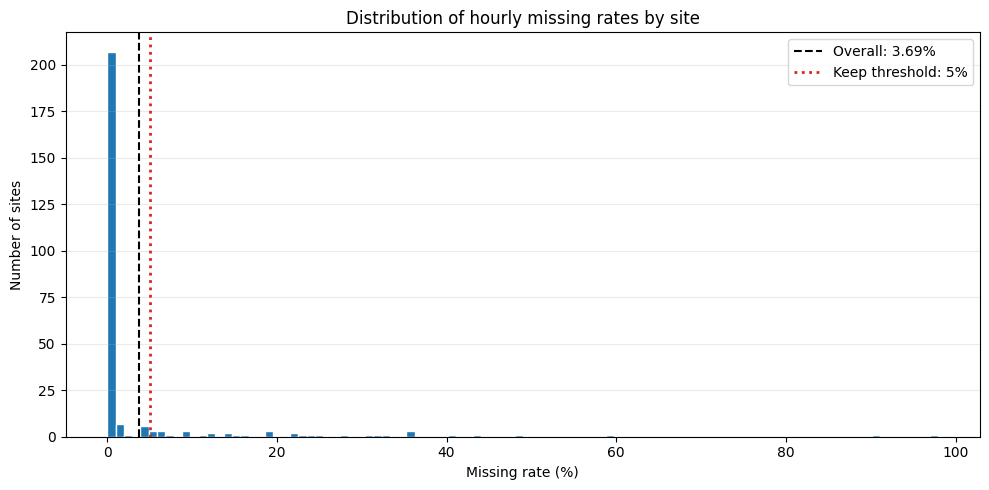

count    259.000000
mean       0.040593
std        0.118770
min        0.000000
25%        0.002854
50%        0.002854
75%        0.004794
max        0.979840
Name: missing_rate, dtype: float64

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(hourly_missing_summary["missing_rate"] * 100, bins=100, edgecolor="white")
ax.axvline(overall_missing_rate * 100, color="black", linestyle="--", linewidth=1.5, label=f"Overall: {overall_missing_rate:.2%}")
ax.axvline(MISSING_RATE_THRESHOLD * 100, color="tab:red", linestyle=":", linewidth=2, label=f"Keep threshold: {MISSING_RATE_THRESHOLD:.0%}")
ax.set_title("Distribution of hourly missing rates by site")
ax.set_xlabel("Missing rate (%)")
ax.set_ylabel("Number of sites")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

hourly_missing_summary["missing_rate"].describe()


In [ ]:
sample_site_ids = (
    calculated_overall_hourly_kept["ee_site_id"]
    .drop_duplicates()
    .sample(n=min(5, calculated_overall_hourly_kept["ee_site_id"].nunique()), random_state=42)
    .tolist()
)

fig, ax = plt.subplots(figsize=(14, 6))
for site_id in sample_site_ids:
    site_ts = (
        calculated_overall_hourly_kept[calculated_overall_hourly_kept["ee_site_id"] == site_id]
        .sort_values("min_t")
    )
    ax.plot(
        site_ts["min_t"],
        site_ts["calculated_overall_power"],
        linewidth=0.8,
        alpha=0.85,
        label=f"Site {site_id}",
    )

ax.set_title("Hourly calculated overall power for 5 sampled sites with <=5% missing data")
ax.set_xlabel("Time")
ax.set_ylabel("Average kW")
ax.grid(True, alpha=0.25)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

sample_site_ids
